# EDA — Distribusi Transaksi Harian & Mingguan per Kategori per User

Analisis distribusi:
1. **Nominal transaksi harian** per kategori (aggregat seluruh user)
2. **Jumlah transaksi per minggu** per kategori per user

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/AI-ENGINEER/data/new'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (77240, 14)
Nasabah   : (500, 11)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail
0,TRX-13215,USR-383,2026-01-01 00:18:00,Debit,JAJANAN GEROBAK,-,5814,"10,323.1","4,721,497.6",Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong
1,TRX-14783,USR-270,2026-01-01 00:20:00,Debit,MIXUE INDONESIA,-,5814,"19,555.3","5,382,262.2",Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong
2,TRX-15292,USR-414,2026-01-01 00:21:00,Debit,MIXUE INDONESIA,-,5814,"29,825.4","13,033,472.4",Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong


In [14]:
# --- Preprocessing ---
df = df_trx.copy()

df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()

# Drop transaksi tanpa kategori
df = df.dropna(subset=['kategori_detail', 'kategori_besar'])

# Fokus ke Debit (pengeluaran)
df_debit = df[df['tipe_mutasi'] == 'Debit'].copy()

KATEGORI_ORDER = sorted(df['kategori_detail'].unique())
print('Kategori Detail:', KATEGORI_ORDER)
print('Rentang tanggal:', df['tanggal'].min(), '-', df['tanggal'].max())

Kategori Detail: ['Belanja Online & Fashion', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Pemasukan Tambahan', 'Pendapatan Bulanan', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']
Rentang tanggal: 2026-01-01 - 2026-03-31


---
## 1. Distribusi Nominal Harian per Kategori (seluruh user)

Setiap titik = total nominal transaksi satu user dalam satu hari untuk satu kategori (Debit).

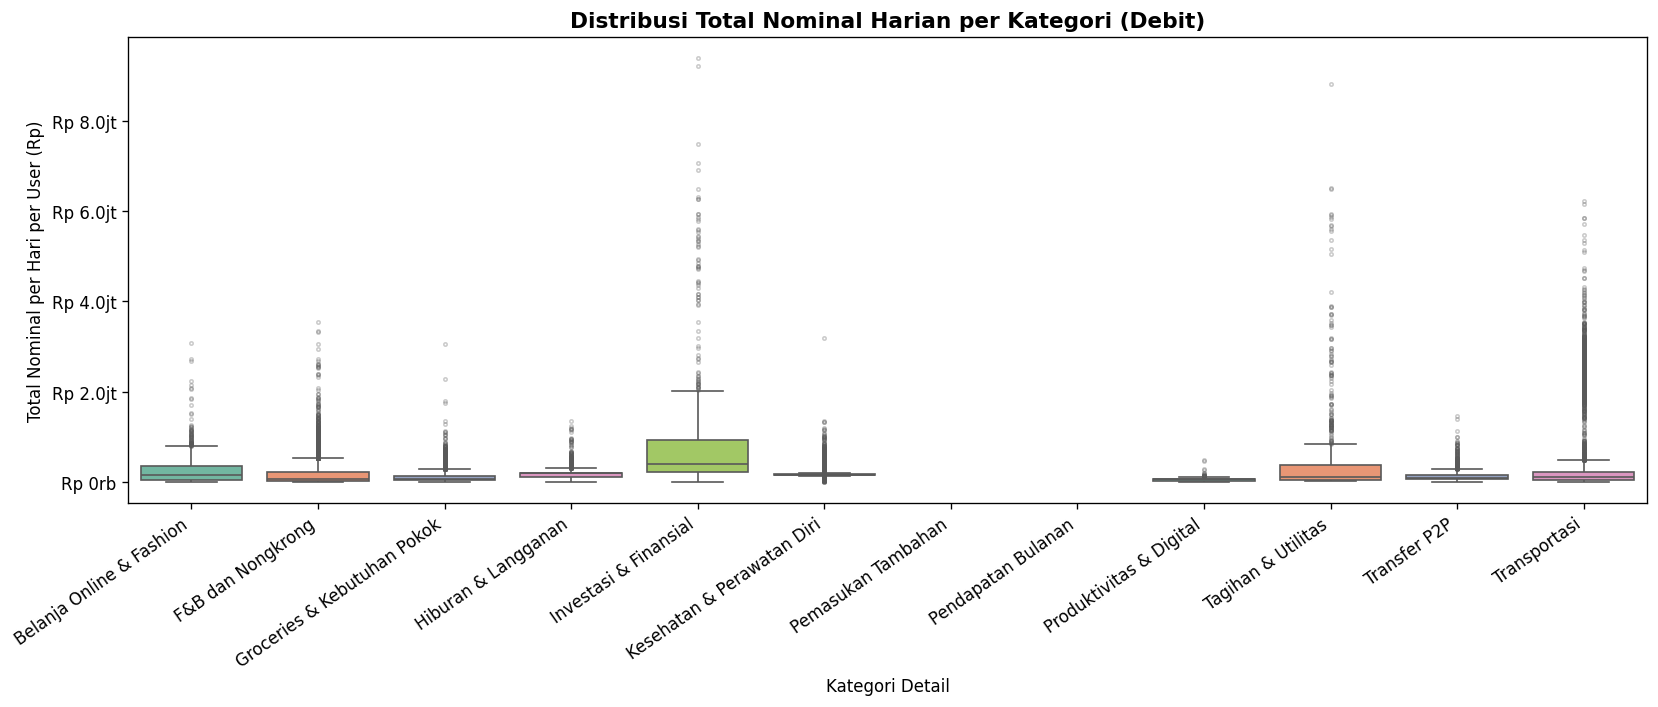


Statistik Nominal Harian per Kategori (Debit):


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"1,977.0","241,052.0","280,484.0","2,000.0","42,294.0","148,932.0","344,930.0","744,841.0","3,066,852.0"
F&B dan Nongkrong,"13,240.0","161,099.0","241,444.0","2,000.0","20,579.0","57,273.0","222,160.0","597,166.0","3,541,333.0"
Groceries & Kebutuhan Pokok,"6,970.0","115,453.0","148,919.0","2,000.0","31,211.0","64,862.0","133,799.0","426,788.0","3,059,704.0"
Hiburan & Langganan,"3,025.0","186,731.0","118,482.0","2,000.0","115,931.0","186,000.0","192,037.0","377,465.0","1,354,340.0"
Investasi & Finansial,"1,311.0","760,321.0","1,050,481.0","3,019.0","207,305.0","399,017.0","931,415.0","2,165,991.0","9,390,866.0"
Kesehatan & Perawatan Diri,"2,542.0","198,180.0","165,050.0","2,000.0","150,000.0","150,000.0","171,846.0","547,436.0","3,191,732.0"
Produktivitas & Digital,750.0,"44,626.0","36,838.0","2,000.0","19,289.0","49,946.0","56,379.0","75,940.0","476,945.0"
Tagihan & Utilitas,646.0,"556,518.0","1,114,096.0","9,487.0","45,000.0","110,619.0","361,418.0","2,879,507.0","8,809,653.0"
Transfer P2P,"4,455.0","117,496.0","103,696.0","2,000.0","53,619.0","90,128.0","148,709.0","290,459.0","1,462,425.0"


In [15]:
# Aggregasi: total nominal per user per tanggal per kategori
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=daily_user_kat,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Nominal Harian per Kategori (Debit):')
daily_user_kat.groupby('kategori_detail')['total_nominal'].describe(
    percentiles=[.25, .5, .75, .95]
).round(0)

---
## 2. Rata-rata Nominal Harian per Kategori — per Hari dalam Seminggu

Heatmap pola pengeluaran berdasarkan hari (Senin–Minggu).

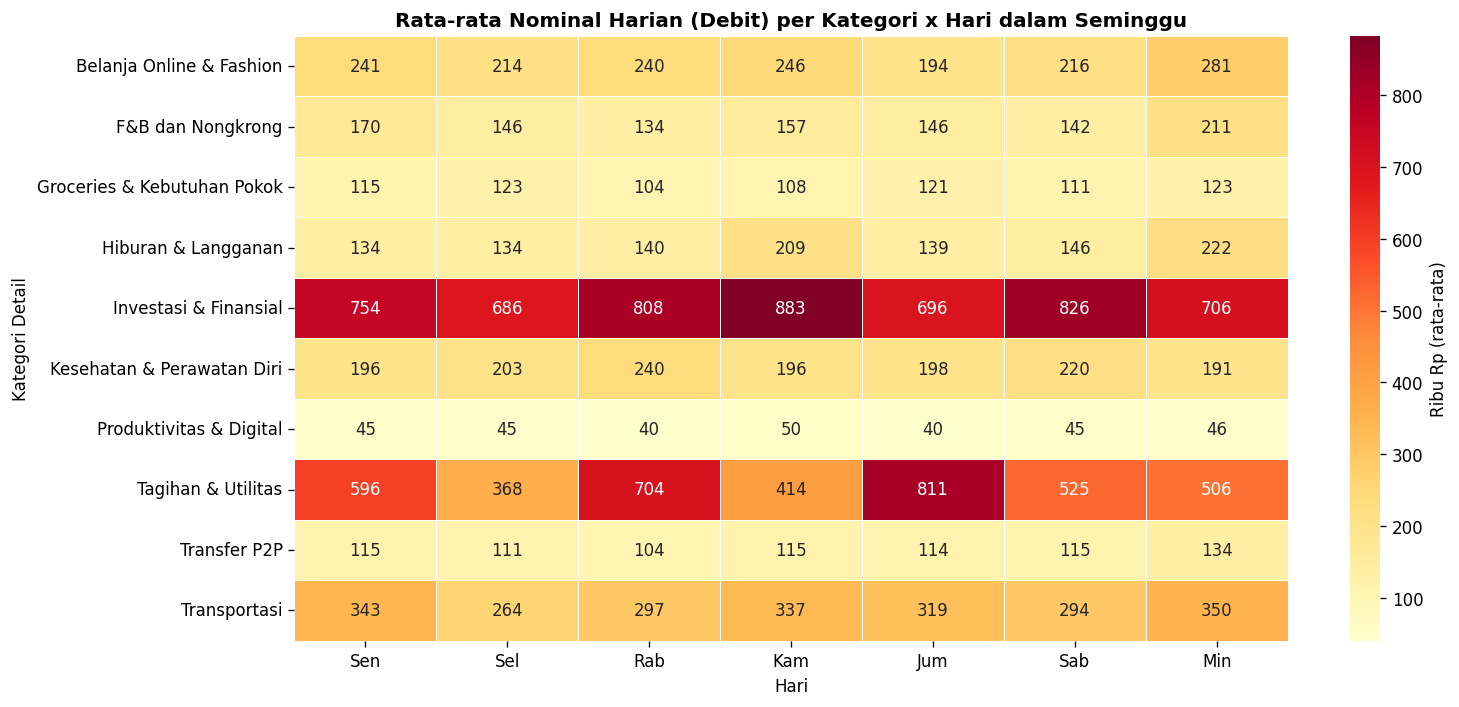

In [16]:
daily_user_kat['hari_nama'] = pd.to_datetime(daily_user_kat['tanggal']).dt.day_name()

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 3. Distribusi Jumlah Transaksi per Minggu per Kategori per User

Setiap titik = jumlah transaksi satu user dalam satu minggu untuk satu kategori.

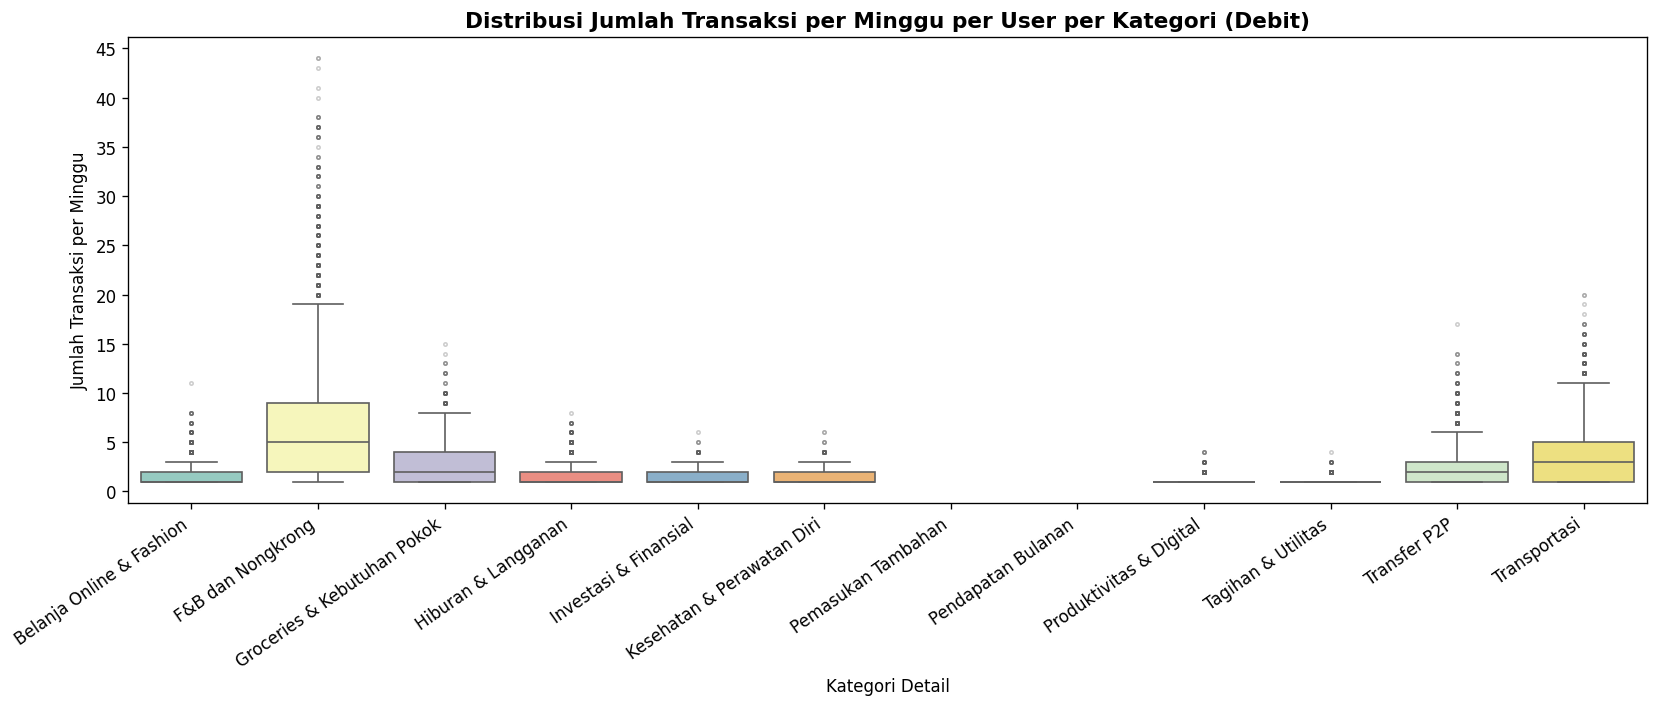


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"1,381.0",1.8,1.3,1.0,1.0,1.0,2.0,4.0,11.0
F&B dan Nongkrong,"4,618.0",6.9,6.4,1.0,2.0,5.0,9.0,20.0,44.0
Groceries & Kebutuhan Pokok,"3,490.0",2.7,2.0,1.0,1.0,2.0,4.0,7.0,15.0
Hiburan & Langganan,"2,307.0",1.7,1.1,1.0,1.0,1.0,2.0,4.0,8.0
Investasi & Finansial,"1,027.0",1.4,0.7,1.0,1.0,1.0,2.0,3.0,6.0
Kesehatan & Perawatan Diri,"2,174.0",1.4,0.7,1.0,1.0,1.0,2.0,3.0,6.0
Produktivitas & Digital,660.0,1.2,0.5,1.0,1.0,1.0,1.0,2.0,4.0
Tagihan & Utilitas,573.0,1.2,0.4,1.0,1.0,1.0,1.0,2.0,4.0
Transfer P2P,"2,555.0",2.6,2.0,1.0,1.0,2.0,3.0,7.0,17.0


In [17]:
# Aggregasi: hitung transaksi per user per minggu per kategori
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

---
## 4. Heatmap — Rata-rata Jumlah Transaksi per Minggu (Kategori x Minggu ke-N)

Tren mingguan masing-masing kategori sepanjang 3 bulan data.

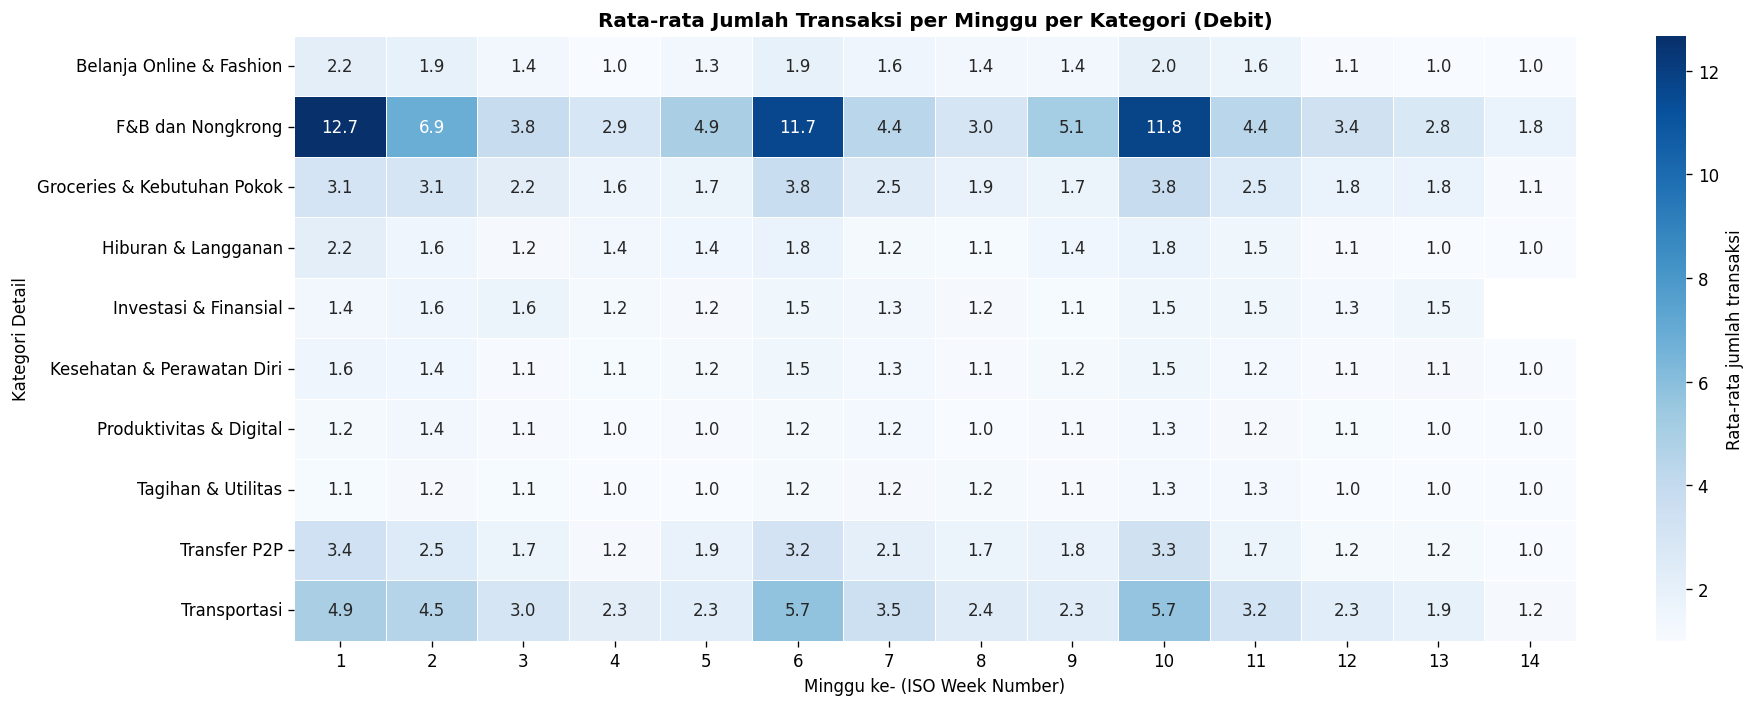

In [18]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 5. Nominal Mingguan per Kategori — Tren & Distribusi Antar-User

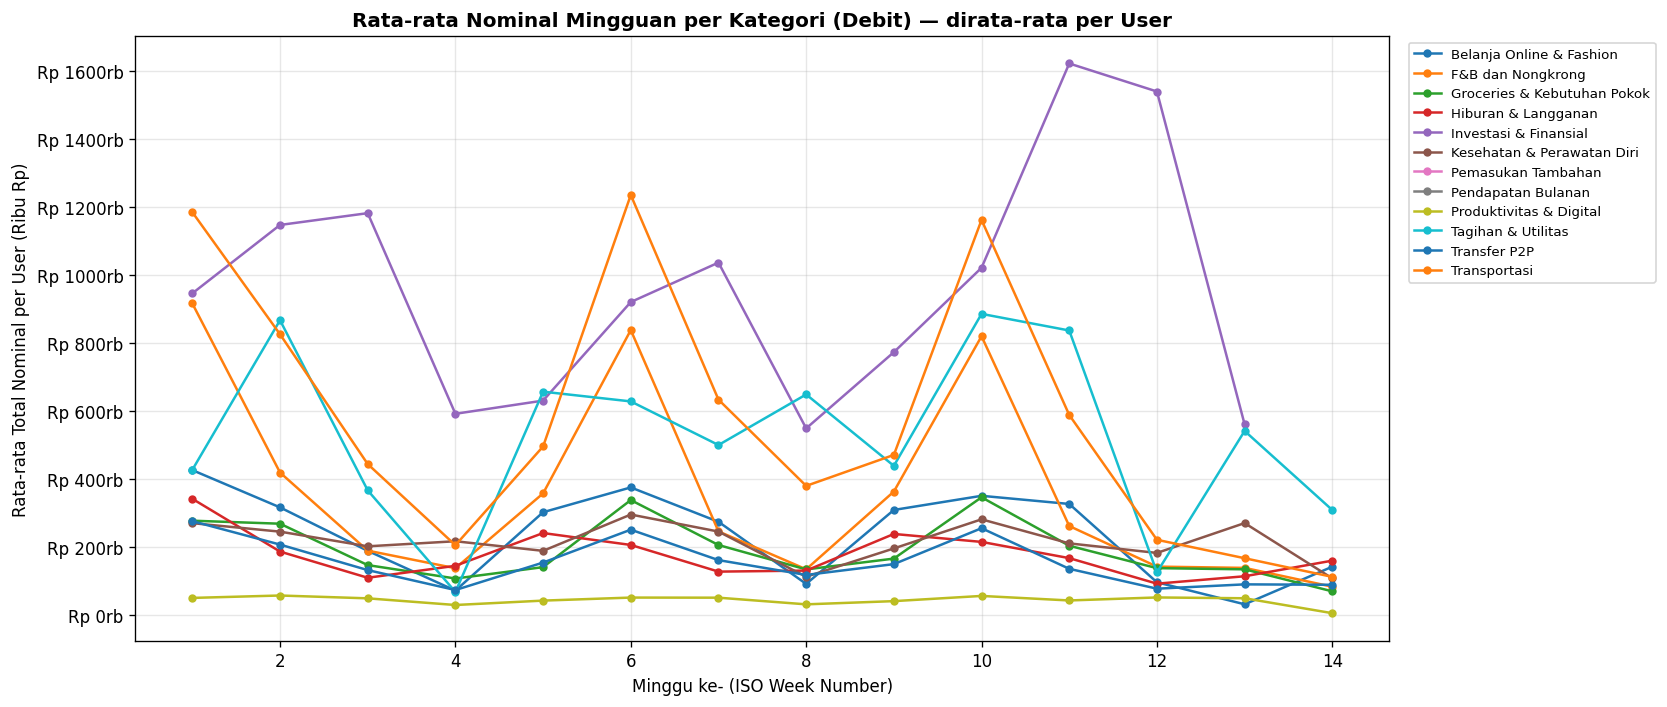

In [19]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

# Line chart rata-rata nominal per minggu per kategori
fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

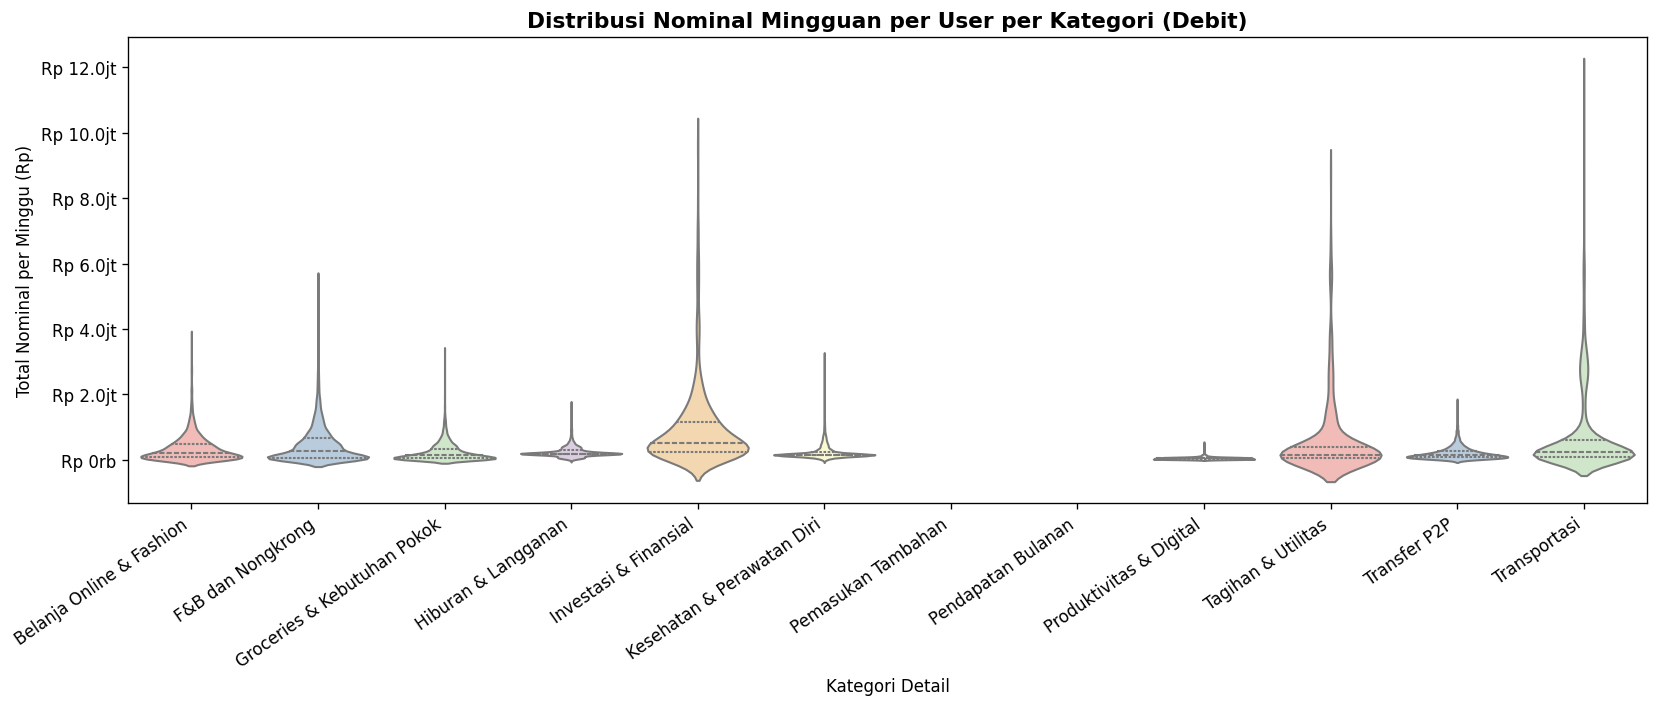

In [20]:
# Violin — distribusi nominal mingguan antar user per kategori
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Rangkuman — Tabel Statistik Mingguan per Kategori

In [21]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"212,311.4","345,082.8","484,227.8","1,080,487.3",1.0,1.8,2.0,4.0
F&B dan Nongkrong,"265,949.4","461,877.2","654,524.9","1,589,752.7",5.0,6.9,9.0,20.0
Groceries & Kebutuhan Pokok,"131,291.4","230,575.1","332,011.4","766,027.8",2.0,2.7,4.0,7.0
Hiburan & Langganan,"186,000.0","244,846.7","293,210.7","545,384.5",1.0,1.7,2.0,4.0
Investasi & Finansial,"514,070.7","970,574.8","1,165,559.0","3,769,701.1",1.0,1.4,2.0,3.0
Kesehatan & Perawatan Diri,"150,000.0","231,727.0","246,492.8","651,742.4",1.0,1.3,2.0,3.0
Produktivitas & Digital,"50,000.0","50,711.6","70,000.0","108,233.9",1.0,1.2,1.0,2.0
Tagihan & Utilitas,"135,528.9","627,418.4","392,331.6","3,168,893.2",1.0,1.2,1.0,2.0
Transfer P2P,"142,233.2","204,870.6","263,796.6","592,132.6",2.0,2.6,3.0,7.0


---
## 7. Rincian per User — Nominal & Jumlah Transaksi per Kategori per Minggu

Tabel pivot per user: baris = kategori, kolom = minggu (sub-kolom: **Nominal** dan **Trx**).

In [22]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1     Minggu 2      Minggu 5      \
                               Nominal Trx  Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion             -   -        -   -  Rp 109rb   1   
F&B dan Nongkrong            Rp 1.78jt  20  Rp 10rb   2  Rp 129rb   3   
Groceries & Kebutuhan Pokok   Rp 224rb   2        -   -         -   -   
Hiburan & Langganan           Rp 301rb   3        -   -  Rp 230rb   2   
Investasi & Finansial                -   -        -   -         -   -   
Kesehatan & Perawatan Diri    Rp 233rb   2        -   -  Rp 150rb   1   
Produktivitas & Digital              -   -        -   -         -   -   
Transfer P2P                  Rp 366rb   5        -   -  Rp 172rb   2   
Transportasi                  Rp 208rb   5        -   -  Rp 185rb   1   

                             Minggu 6     Minggu 7     Minggu 8      \
                              Nominal Trx  Nominal Trx  Nominal Trx   
Kategori                                                              
Belanja Online & Fashion     Rp 366rb   1        -   -        -   -   
F&B dan Nongkrong            Rp 922rb  12  Rp 97rb   3        -   -   
Groceries & Kebutuhan Pokok   Rp 99rb   3  Rp 48rb   2  Rp 34rb   1   
Hiburan & Langganan          Rp 250rb   1        -   -        -   -   
Investasi & Finansial               -   -        -   -        -   -   
Kesehatan & Perawatan Diri          -   -        -   -        -   -   
Produktivitas & Digital             -   -        -   -        -   -   
Transfer P2P                  Rp 79rb   1        -   -        -   -   
Transportasi                 Rp 257rb   2        -   -        -   -   

                              Minggu 9     Minggu 10      
                               Nominal Trx   Nominal Trx  
Kategori                                                  
Belanja Online & Fashion             -   -         -   -  
F&B dan Nongkrong            Rp 1.21jt   8  Rp 849rb   6  
Groceries & Kebutuhan Pokok   Rp 120rb   4         -   -  
Hiburan & Langganan           Rp 186rb   1         -   -  
Investasi & Finansial         Rp 364rb   1         -   -  
Kesehatan & Perawatan Diri    Rp 269rb   2   Rp 34rb   1  
Produktivitas & Digital              -   -   Rp 29rb   1  
Transfer P2P                  Rp 217rb   3   Rp 22rb   1  
Transportasi                  Rp 364rb   5  Rp 282rb   4


  USER: USR-002


Minggu 1     Minggu 2      Minggu 5      \
                               Nominal Trx  Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion       Rp 93rb   2        -   -  Rp 134rb   1   
F&B dan Nongkrong            Rp 1.31jt  16        -   -  Rp 332rb   6   
Groceries & Kebutuhan Pokok          -   -        -   -    Rp 7rb   1   
Hiburan & Langganan           Rp 420rb   2        -   -  Rp 186rb   1   
Kesehatan & Perawatan Diri    Rp 150rb   1        -   -  Rp 150rb   1   
Produktivitas & Digital              -   -        -   -         -   -   
Tagihan & Utilitas             Rp 84rb   1        -   -         -   -   
Transfer P2P                   Rp 19rb   1        -   -  Rp 397rb   3   
Transportasi                  Rp 115rb   1   Rp 3rb   1  Rp 329rb   4   

                             Minggu 6     Minggu 7      Minggu 9      \
                              Nominal Trx  Nominal Trx   Nominal Trx   
Kategori                                                               
Belanja Online & Fashion      Rp 10rb   1        -   -         -   -   
F&B dan Nongkrong            Rp 529rb  11   Rp 4rb   1  Rp 237rb   6   
Groceries & Kebutuhan Pokok  Rp 174rb   2        -   -  Rp 312rb   1   
Hiburan & Langganan          Rp 132rb   1        -   -  Rp 186rb   1   
Kesehatan & Perawatan Diri    Rp 80rb   1        -   -  Rp 150rb   1   
Produktivitas & Digital       Rp 27rb   1        -   -   Rp 23rb   1   
Tagihan & Utilitas                  -   -        -   -         -   -   
Transfer P2P                  Rp 90rb   2        -   -   Rp 95rb   1   
Transportasi                 Rp 207rb   3        -   -   Rp 71rb   2   

                            Minggu 10      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 432rb   5  
Groceries & Kebutuhan Pokok   Rp 15rb   3  
Hiburan & Langganan          Rp 192rb   1  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                 Rp 213rb   3  
Transportasi                 Rp 276rb   2